## Assignment:
### Urban Architecture Failure

In [ ]:
# We will first import all the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

#### Will load the data

In [ ]:
# Will also first launch the google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Lets access the data from google drive and import the file.
urban = pd.read_csv('/content/drive/MyDrive/ITNPBD6_Final_ML/urbandata.csv')
urban.head()    # To display first 5 rows of the imported dataset

,inspector_id,material_flexibility,structural_mass_ratio,recent_precipitation,infrastructure_age,surface_debris,vibration_exposure,asset_density,inspection_season,inspection_window,moisture_stress,failure
0,5,31.762605,12.891996,4.711064,71.480592,9.429642,5.177088,2.9944,summer,afternoon,0.06,1
1,7,30.770158,11.835563,3.315888,60.300892,8.655641,4.927622,2.6808,spring,morning,0.01,0
2,6,31.591296,11.738267,2.425562,56.367965,9.017137,4.910945,2.5294,autumn,night,0.02,0
3,5,30.834649,11.622881,2.164486,53.135138,8.864650,4.949554,2.4810,autumn,afternoon,0.02,1
4,2,33.315981,12.616065,4.557082,77.482269,9.549344,5.047689,3.0460,summer,morning,0.07,1


In [ ]:
print (f'Rows: {urban.shape[0]}')
print (f'Columns: {urban.shape[1]}')

Rows: 456
Columns: 12


In [ ]:
print (urban.dtypes)    # to check the datatypes of the colums

inspector_id               int64
material_flexibility     float64
structural_mass_ratio    float64
recent_precipitation     float64
infrastructure_age       float64
surface_debris           float64
vibration_exposure       float64
asset_density            float64
inspection_season         object
inspection_window         object
moisture_stress          float64
failure                    int64
dtype: object


In [ ]:
print(urban.describe())    # For the basic statistics

       inspector_id  material_flexibility  structural_mass_ratio  \
count    456.000000            456.000000             455.000000   
mean       5.730263             32.592037              12.089241   
std        2.921622              4.738187               0.591701   
min        1.000000             24.924765              11.506094   
25%        3.000000             30.496861              11.672524   
50%        6.000000             31.902116              11.863909   
75%        8.000000             34.026756              12.332858   
max       11.000000             91.157913              14.823489   

       recent_precipitation  infrastructure_age  surface_debris  \
count            454.000000          452.000000      456.000000   
mean               3.110861           68.532487        9.271769   
std                1.365354           14.490899        0.790136   
min                0.000000           41.087602        7.426926   
25%                2.140594           58.594494     

In [ ]:
# To check the duplicates in row
print (f'Duplicate rows found: {urban.duplicated().sum()}')

Duplicate rows found: 0


In [ ]:
# Lets check the missing values
print (urban.isnull().sum())

inspector_id             0
material_flexibility     0
structural_mass_ratio    1
recent_precipitation     2
infrastructure_age       4
surface_debris           0
vibration_exposure       1
asset_density            0
inspection_season        0
inspection_window        0
moisture_stress          3
failure                  0
dtype: int64


In [ ]:
# Rather than dropping the entire row to clean the data
# Or using mean which can be more prone for outliers
# Lets use the median value to impute the missing values as more snsible robust method.

urban['structural_mass_ratio'] = urban['structural_mass_ratio'].fillna(urban['structural_mass_ratio'].median())
urban['recent_precipitation'] = urban['recent_precipitation'].fillna(urban['recent_precipitation'].median())
urban['infrastructure_age'] = urban['infrastructure_age'].fillna(urban['infrastructure_age'].median())
urban['vibration_exposure'] = urban['vibration_exposure'].fillna(urban['vibration_exposure'].median())
urban['moisture_stress'] = urban['moisture_stress'].fillna(urban['moisture_stress'].median())

# Lets check the missing values again in the main dataset
urban.isnull().sum()

,0
inspector_id,0
material_flexibility,0
structural_mass_ratio,0
recent_precipitation,0
infrastructure_age,0
surface_debris,0
vibration_exposure,0
asset_density,0
inspection_season,0
inspection_window,0


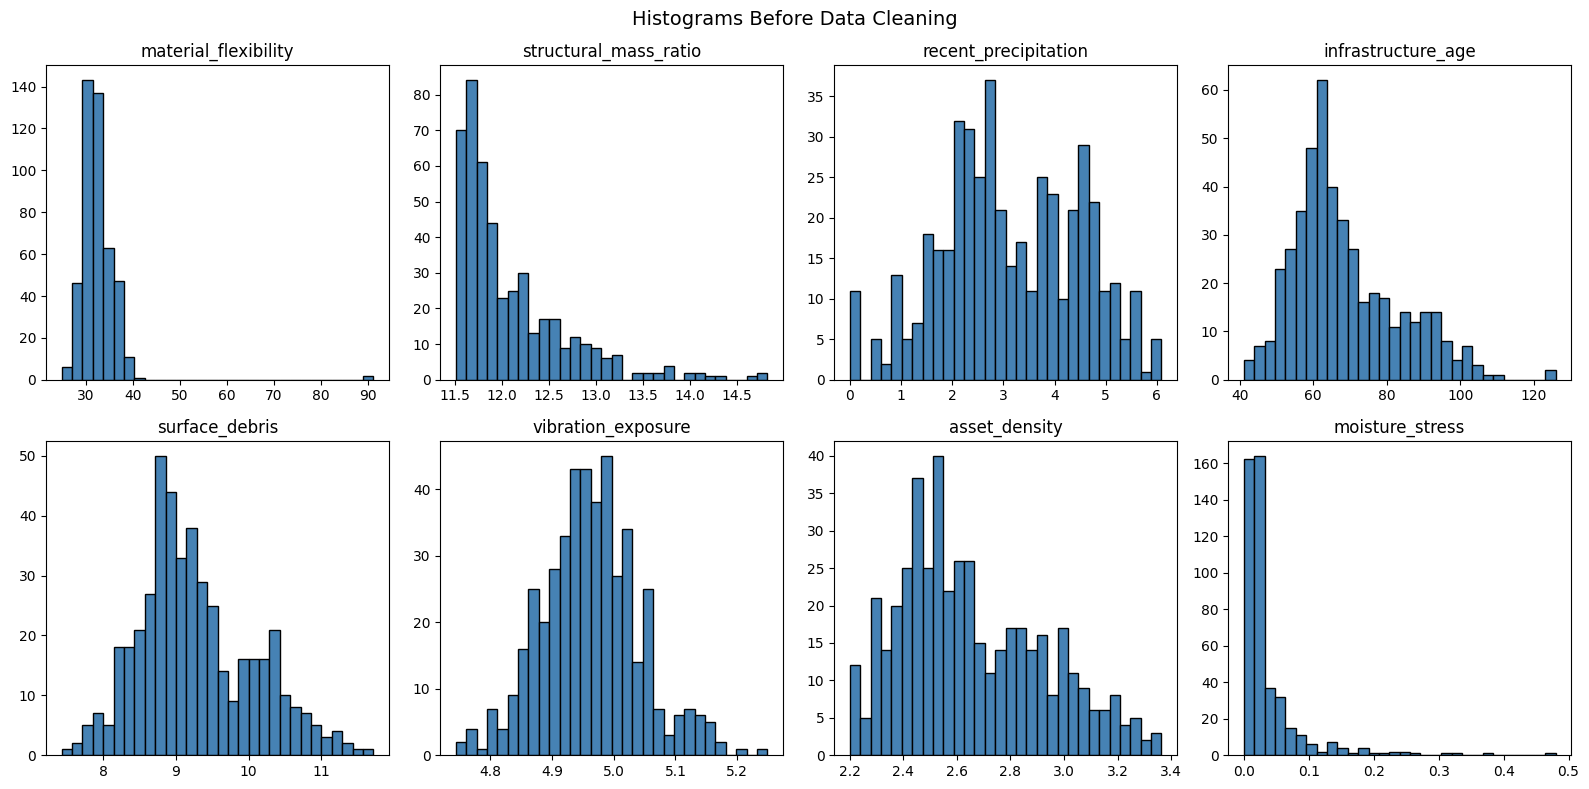

In [ ]:
# Lets list the numeric columns to visualise them after we worked on null values

numeric_cols = ['material_flexibility', 'structural_mass_ratio',
                'recent_precipitation', 'infrastructure_age',
                'surface_debris', 'vibration_exposure',
                'asset_density', 'moisture_stress']

# Will create a a grid of 8 subplots
fig, axes = plt.subplots(2, 4, figsize=(16, 8))    # 2 rows and 4 columns
fig.suptitle('Histograms Before Data Cleaning', fontsize=14)

# Will create a loop for histograms
for i, col in enumerate(numeric_cols):
    row = i // 4
    col_idx = i % 4
    axes[row, col_idx].hist(urban[col], bins=30, color='steelblue', edgecolor='black')
    axes[row, col_idx].set_title(col)

plt.tight_layout()
plt.show()

In [49]:
from numpy._core.fromnumeric import mean
# We can see that material_flexibility, infrastructure_age and moisture_stress have obvious outliers
# So lets check them

print(urban['material_flexibility'].describe())
mean_val = urban['material_flexibility'].mean()
std_val = urban['material_flexibility'].std()
threshold = mean_val + 3 * std_val

print(f"nMean: {mean_val:.2f}, Std: {std_val:.2f}")
print(f"Threshold: {threshold:.2f}")
print(urban[urban['material_flexibility'] > threshold][['inspector_id','material_flexibility']])

count    456.000000
mean      32.592037
std        4.738187
min       24.924765
25%       30.496861
50%       31.902116
75%       34.026756
max       91.157913
Name: material_flexibility, dtype: float64
nMean: 32.59, Std: 4.74
Threshold: 46.81
     inspector_id  material_flexibility
9               2             91.157913
421             5             91.157913
